### Data Loading

In [90]:
import pandas as pd

file_path = 'data/ai_student_impact_dataset.csv'
csvFile = pd.read_csv(file_path)
csvFile.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [91]:
# explore the columns and dataset

csvFile.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')

### Exploratory Data Analysis (EDA)

In [92]:
# create a copy of dataset
df_original_ai = csvFile

# see the data types
df_original_ai.dtypes

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object

In [93]:
# Missing values

missing = df_original_ai.isnull().sum()

print("Missing Values:")
print(missing[missing>0] if missing.sum()> 0 else "No missing values")


Missing Values:
No missing values


In [94]:
df_original_ai['Major_Category'].unique().tolist()

['Humanities', 'Medical', 'Business', 'STEM', 'Arts']

In [95]:
df_original_ai['Burnout_Risk_Level'].unique().tolist()

['High', 'Low', 'Medium']

In [96]:
df_original_ai['Year_of_Study'].unique().tolist()

['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate']

In [97]:
df_original_ai['Anxiety_Level_During_Exams'].unique().tolist()

[6, 9, 2, 4, 5, 7, 1, 8, 3, 10]

In [98]:
df_original_ai['Primary_Use_Case'].unique().tolist()

['Copywriting/Drafting',
 'Ideation',
 'Summarizing_Reading',
 'Debugging/Troubleshooting',
 'Direct_Answer_Generation']

In [99]:
df_original_ai['Institutional_Policy'].unique().tolist()

['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged']

In [100]:
df_original_ai.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [101]:
df_original_ai.nunique()

Student_ID                    50000
Major_Category                    5
Year_of_Study                     5
Pre_Semester_GPA               2389
Weekly_GenAI_Hours             3566
Primary_Use_Case                  5
Prompt_Engineering_Skill          3
Tool_Diversity                    5
Paid_Subscription                 2
Traditional_Study_Hours        2516
Perceived_AI_Dependency          10
Institutional_Policy              3
Anxiety_Level_During_Exams       10
Post_Semester_GPA              2269
Skill_Retention_Score          5872
Burnout_Risk_Level                3
dtype: int64

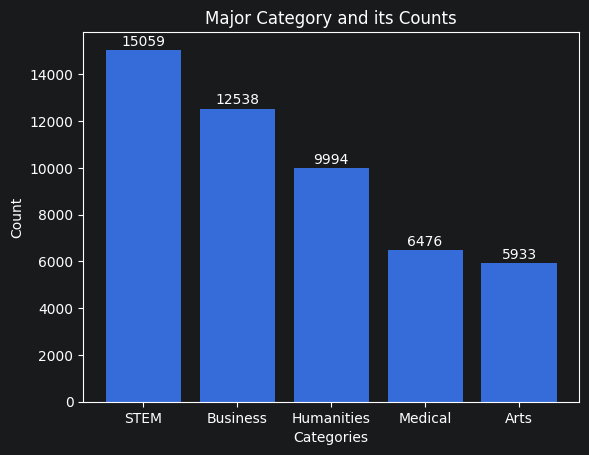

In [102]:
# plot a bar chart to show the distribution of majors

import matplotlib.pyplot as plt

values = df_original_ai['Major_Category'].value_counts()

fig, ax = plt.subplots()
bars = ax.bar(values.index, values.values)

ax.set_title('Major Category and its Counts')
ax.set_xlabel('Categories')
ax.set_ylabel('Count')

ax.bar_label(bars, labels=[v for v in values], padding=1)
plt.xticks(rotation=0)

plt.show()

In [103]:
## Do students who use GenAI more hours per week also feel more dependent on it?

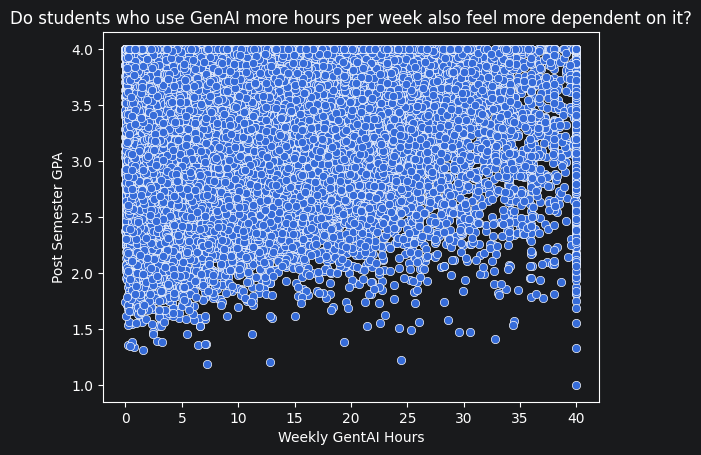

In [104]:
import seaborn as sns

sns.scatterplot(data=df_original_ai, x='Weekly_GenAI_Hours', y='Post_Semester_GPA')

plt.title('Do students who use GenAI more hours per week also feel more dependent on it?')
plt.xlabel('Weekly GentAI Hours')
plt.ylabel('Post Semester GPA')
plt.show()


In [105]:
## It shows a random blob. This means that there is no correlation between GPA and AI usage. More AI usage doesn't mean better grades.

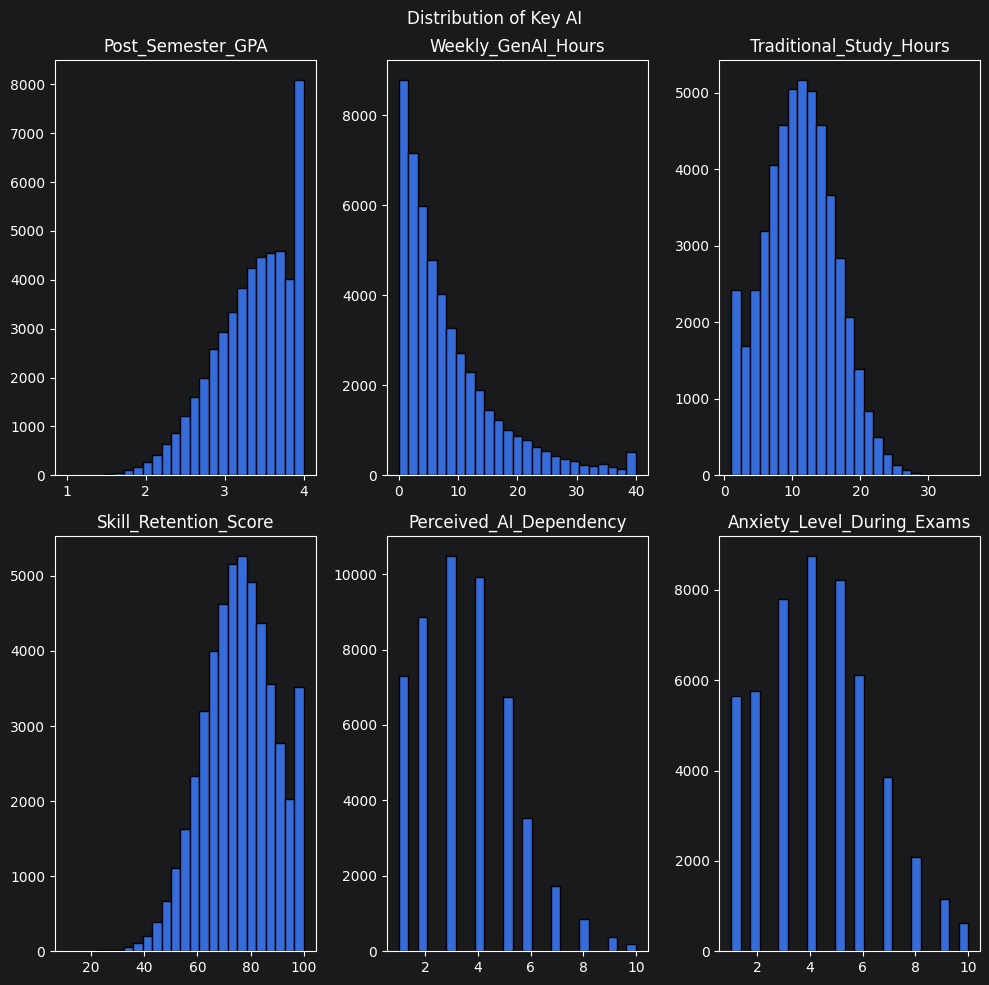

In [106]:
# Which major uses GenAI the most?

import matplotlib.pyplot as plt

num_cols = [
    "Post_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Skill_Retention_Score",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams"
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10,10))
fig.suptitle('Distribution of Key AI')

for i, ax in enumerate(axes.flatten()):
    if i >= len(num_cols):
        ax.axis('off')
        continue
    col = num_cols[i]

    ax.hist(df_original_ai[col], bins=25, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [107]:
# Most students score around 4.0 GPA, the distribution skews right (most students do well)
# Majority use AI for 0–5 hours per week, very few use it beyond 20 hours
# Most students score between 70–85, so retention is generally decent
# Most students rate their dependency around 3–4 out of 10, so moderate
# Peaks at around 4 out of 10, so mild-to-moderate anxiety is most common

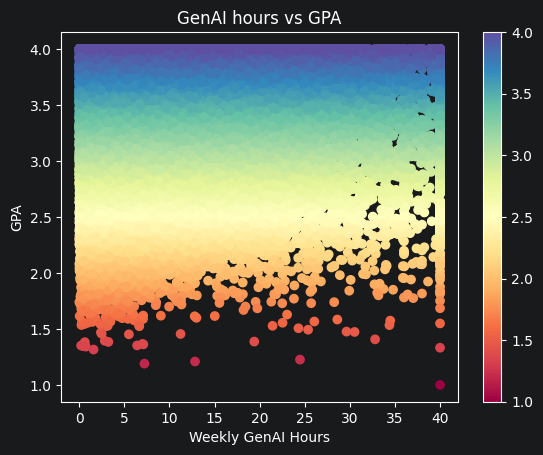

In [108]:
# Compare GenAI hours vs GPA

ai = df_original_ai['Weekly_GenAI_Hours']
hours  = df_original_ai['Post_Semester_GPA']
plt.scatter(ai,hours, c=hours, cmap='Spectral')

plt.colorbar()
plt.title('GenAI hours vs GPA')
plt.xlabel('Weekly GenAI Hours')
plt.ylabel('GPA')

plt.show()

In [109]:
# If AI usage helped students get better grades, we would expect to see the dots go upward from left to right. Instead we see a filled blob, meaning GPA is completely unrelated to how many hours a student uses AI per week.

In [110]:
# change in GPA

df_original_ai['GPA_Change'] = df_original_ai['Pre_Semester_GPA']- df_original_ai['Post_Semester_GPA']

df_summary = df_original_ai.groupby('Major_Category')[['Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_Change']].mean().reset_index()


print(df_summary)

  Major_Category  Pre_Semester_GPA  Post_Semester_GPA  GPA_Change
0           Arts          3.146786           3.343688   -0.196902
1       Business          3.141760           3.336085   -0.194325
2     Humanities          3.147850           3.345825   -0.197976
3        Medical          3.151769           3.353168   -0.201399
4           STEM          3.145852           3.363154   -0.217302


In [111]:
df_original_ai.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Change
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125,-0.203197
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626,0.187192
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000,-1.008000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000,-0.325000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000,-0.204000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000,-0.087000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000,0.924000


<Axes: >

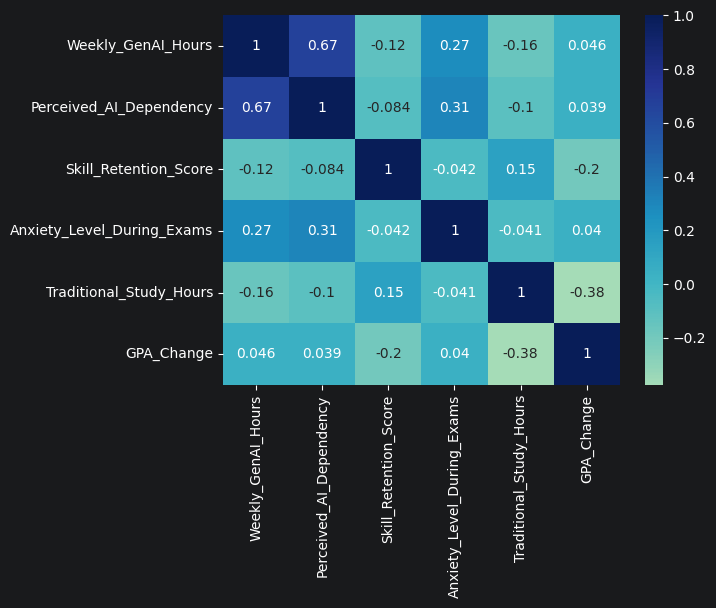

In [112]:
import seaborn as sns

num_cols = ['Weekly_GenAI_Hours', 'Perceived_AI_Dependency','Skill_Retention_Score', 'Anxiety_Level_During_Exams','Traditional_Study_Hours', 'GPA_Change']
corr = df_original_ai[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='YlGnBu', center=0)

### Statistical Analysis

In [114]:
# Do students with different levels of AI usage have different average GPA changes?

from scipy.stats import f_oneway

groups = [
    df_original_ai[df_original_ai['Perceived_AI_Dependency'] == dep]['GPA_Change']
    for dep in df_original_ai['Perceived_AI_Dependency'].unique()
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value:.4f}")
print(f"P_value 2: {p_value}")

if p_value < 0.05:
    print("There is a significant difference in GPA Change across AI dependency levels.")
else:
    print("There is no significant difference in GPA Change across AI dependency levels.")

group_means = df_original_ai.groupby('Perceived_AI_Dependency')['GPA_Change'].mean()

print("\n Average GPA change by AI Usage Level:")
print(group_means)

F-statistic: 26.02025121214268
P-value: 0.0000
P_value 2: 2.798939775668423e-45
There is a significant difference in GPA Change across AI dependency levels.

 Average GPA change by AI Usage Level:
Perceived_AI_Dependency
1    -0.202674
2    -0.204884
3    -0.210171
4    -0.208057
5    -0.207944
6    -0.196108
7    -0.168888
8    -0.160255
9    -0.135233
10   -0.108079
Name: GPA_Change, dtype: float64


In [ ]:
# The ANOVA test showed a statistically significant difference in GPA change across levels of perceived AI dependency (F = 26.02, p < 0.001 or or p ≈ 2.8 × 10⁻⁴⁵).

# The results indicate a clear trend where students with higher AI dependency levels tend to experience a smaller decline in GPA compared to those with lower dependency levels. However, GPA change remains negative across all groups.

In [115]:
corr = df_original_ai['Weekly_GenAI_Hours'].corr(
    df_original_ai['GPA_Change']
)

print(f"Correlation: {corr:.3f}")

Correlation: 0.046


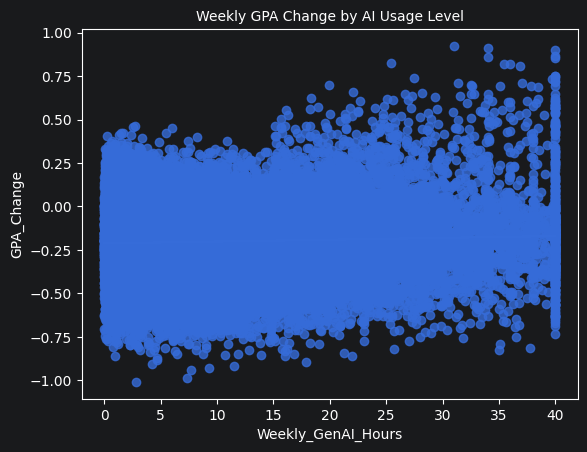

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df_original_ai,
    x = 'Weekly_GenAI_Hours',
    y = 'GPA_Change',
)

plt.title('Weekly GPA Change by AI Usage Level', fontsize=10, loc='center')
plt.show()

In [ ]:
# Do burnout levels differ between heavy AI users and light AI users?

In [120]:
df_original_ai.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'GPA_Change'],
      dtype='str')

In [121]:
df_original_ai.dtypes

Student_ID                      int64
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
GPA_Change                    float64
dtype: object

In [125]:
df_original_ai['AI_Usage_Group'] = pd.cut(
    df_original_ai['Weekly_GenAI_Hours'],
    bins=[0,5,15,100],
    labels=['Light', 'Medium','Heavy']
)

In [122]:
df_original_ai['Burnout_Risk_Level'].unique()

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

In [131]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_original_ai['AI_Usage_Group'],
    df_original_ai['Burnout_Risk_Level']
)

chi2, p, dof, expected = chi2_contingency(table)

 # print(p)

alpha = 0.05
print(f'p value is {p:.2e}')

if p <= alpha:
    print('Dependent (reject HO)')
else:
    print('Independent (H0 holds true)')

p value is 0.00e+00
Dependent (reject HO)


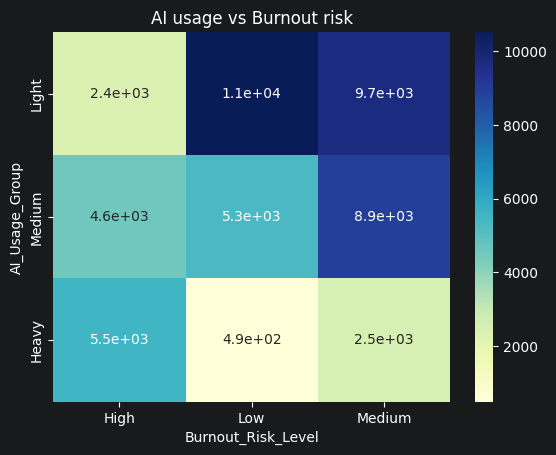

In [132]:
sns.heatmap(table, annot=True, cmap='YlGnBu')
plt.title("AI usage vs Burnout risk")
plt.show()

In [ ]:
# Burnout levels and AI usage are not independent. Students who use IA at different levels tend to show different burnout levels, and this difference is statistically significant.

In [ ]:
# Do students who use AI frequently have higher GPAs than students who rarely use AI?